#  PyTorch Lightning

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://lightning.ai/docs/pytorch/stable/starter/introduction.html
* https://lightning.ai/docs/pytorch/stable/levels/core_skills.html
* https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.core.LightningModule.html#lightning.pytorch.core.LightningModule.log
* https://lightning.ai/docs/pytorch/stable/extensions/logging.html
* https://lightning.ai/docs/pytorch/stable/common/progress_bar.html
* https://lightning.ai/docs/pytorch/stable/common/early_stopping.html
* https://lightning.ai/docs/pytorch/1.6.3/api/pytorch_lightning.utilities.model_summary.html#pytorch_lightning.utilities.model_summary.ModelSummary
* https://torchmetrics.readthedocs.io/en/stable/pages/lightning.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/
* https://www.youtube.com/watch?v=XbIN9LaQycQ&list=PLhhyoLH6IjfyL740PTuXef4TstxAK6nGP
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/data/datamodule.html

## Задачи для совместного разбора

1\. Создайте датасет для классификации и обучите модель при помощи PyTorch Lightning.

In [134]:
!pip install pytorch_lightning

In [135]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from typing import Any, List, Optional, Union
import pytorch_lightning as pl

pl.seed_everything(42)

# создание простого датасета для классификации
class MyDataset(Dataset):
    def __init__(self, num_samples: int = 1000):
        """
        каждый объект имеет 2 признака
        класс определяется по правилу:
        если сумма признаков > 0, то класс 1, иначе 0
        """
        super().__init__()

        # генерируем случайные признаки
        self.X = torch.randn(num_samples, 2)

        # формируем метки классов
        # .long() нужен для CrossEntropyLoss
        self.y = (self.X[:, 0] + self.X[:, 1] > 0).long()

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [136]:
class MyLightningModule(pl.LightningModule):
    """
    класс модуля pytorch lightning
    определяет модель, шаги обучения/валидации/тестирования
    """

    def __init__(self):
        """
        здесь определяется архитектура модели и функция потерь
        """
        super().__init__()

        # модель для классификации
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

        # функция потерь
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        прямой проход модели

        args:
            x (torch.Tensor): входной тензор

        returns:
            torch.Tensor: выход модели (логиты)
        """
        return self.model(x)

    def training_step(self, batch: Any, batch_idx: int) -> torch.Tensor:
        """
        один шаг обучения

        args:
            batch (Any): батч данных
            batch_idx (int): индекс батча

        returns:
            torch.Tensor: значение функции потерь
        """
        x, y = batch

        # прямой проход
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean() # accuracy

        # логируем метрики
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)

        return loss

    def validation_step(self, batch: Any, batch_idx: int) -> None:
        """
        один шаг валидации

        args:
            batch (Any): батч данных
            batch_idx (int): индекс батча
        """
        x, y = batch

        # прямой проход
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean() # accuracy

        # логируем метрики
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch: Any, batch_idx: int) -> None:
        """
        один шаг тестирования

        args:
            batch (Any): батч данных
            batch_idx (int): индекс батча
        """
        x, y = batch

        # прямой проход
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean() # accuracy

        # логируем метрики
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)

    def configure_optimizers(self) -> torch.optim.Optimizer:
        """
        настраивает оптимизатор

        returns:
            torch.optim.Optimizer: оптимизатор adam
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)
        return optimizer

In [137]:
class MyDataModule(pl.LightningDataModule):
    """
    класс модуля данных pytorch lightning
    отвечает за подготовку данных и dataloader
    """

    def __init__(self, batch_size: int = 32):
        """
        инициализация модуля данных

        args:
            batch_size (int): размер батча
        """
        super().__init__()
        self.batch_size = batch_size

        # сюда позже будут записаны выборки
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None

        print("batch_size:", self.batch_size)

    def prepare_data(self) -> None:
        """
        подготовка данных
        """

    def setup(self, stage: Optional[str] = None) -> None:
        """
        настройка данных для этапов fit/test

        args:
            stage (Optional[str]): этап ('fit', 'test' или None)
        """
        # создаём полный датасет
        full_dataset = MyDataset(num_samples=1000)

        # размеры частей
        train_size = int(0.7 * len(full_dataset))
        val_size = int(0.15 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size

        # делим датасет
        self.train_dataset, self.val_dataset, self.test_dataset = random_split(
            full_dataset,
            [train_size, val_size, test_size]
        )

        print("train:", len(self.train_dataset))
        print("val:", len(self.val_dataset))
        print("test:", len(self.test_dataset))

    def train_dataloader(self) -> DataLoader:
        """
        dataloader для обучающей выборки

        returns:
            DataLoader: dataloader для train
        """
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self) -> DataLoader:
        """
        dataloader для валидационной выборки

        returns:
            DataLoader: dataloader для val
        """
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self) -> DataLoader:
        """
        dataloader для тестовой выборки

        returns:
            DataLoader: dataloader для test
        """
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

In [138]:
# создание объектов модели и данных

# создаем модуль данных
data_module = MyDataModule(batch_size=32)

# создаем модель
model = MyLightningModule()

batch_size: 32


In [139]:
# создание trainer и обучение модели

trainer = pl.Trainer(
max_epochs=10,
enable_checkpointing=False,
logger=False
)

# обучение модели
trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


train: 700
val: 150
test: 150


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │     42 │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 42                                                                                               
Non-trainable params: 0                                                                                            
Total params: 42                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [140]:
# тестирование модели
trainer.test(model, datamodule=data_module)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9933333396911621     │
│         test_loss         │   0.037227604538202286    │
└───────────────────────────┴───────────────────────────┘

train: 700
val: 150
test: 150


[{'test_loss': 0.037227604538202286, 'test_acc': 0.9933333396911621}]

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите набор данных из файла `Walmart.csv`. Выполните следующую процедуру предобработки:
- замените цены `Weekly_Sales` на логарифм цены;
- удалите столбец с датами;
- закодируйте столбцы `Store` и `Holiday_Flag` при помощи `TargetEncoder` (см. пакет [category_encoders](https://contrib.scikit-learn.org/category_encoders/));
- после кодирование выполните стандартизацию признаков;
- разбейте выборку на обучающее, валидационное и тестовое множество.

Все преобразования допускает делать при помощи `numpy`, `pandas` и `sklearn`.

- [ ] Проверено на семинаре

In [141]:
!pip install category_encoders

In [142]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

In [143]:
df = pd.read_csv("Walmart_sales.csv")
print("размер таблицы:", df.shape)

размер таблицы: (6435, 8)


In [144]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [145]:
# приведение числовых столбцов к числовому типу
numeric_cols = [
    "Store",
    "Weekly_Sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


In [146]:
print("количество пропусков по столбцам:")
df.isna().sum()

количество пропусков по столбцам:


,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [147]:
# заменяем Weekly_Sales на натуральный логарифм

df["Weekly_Sales"] = np.log(df["Weekly_Sales"])
df["Weekly_Sales"].head()

,Weekly_Sales
0,14.312455
1,14.311400
2,14.292966
3,14.158907
4,14.256862


In [148]:
# удаляем столбец Date
df = df.drop(columns=["Date"])
df.columns.tolist()

['Store',
 'Weekly_Sales',
 'Holiday_Flag',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment']

In [149]:
# целевая переменная
y = df["Weekly_Sales"]

# признаки
X = df.drop(columns=["Weekly_Sales"])

print("размер X:", X.shape)
print("размер y:", y.shape)

размер X: (6435, 6)
размер y: (6435,)


In [150]:
# деление на train, test, val

# сначала отделяем test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

# из оставшихся данных выделяем val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.17,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (4539, 6)
X_val: (930, 6)
X_test: (966, 6)
y_train: (4539,)
y_val: (930,)
y_test: (966,)


In [151]:
# кодирование Store и Holiday_Flag через TargetEncoder
# TargetEncoder обучаем только на train

# столбцы для target encoding
cat_cols = ["Store", "Holiday_Flag"]
target_encoder = TargetEncoder(cols=cat_cols)
X_train_encoded = target_encoder.fit_transform(X_train, y_train)

# для val и test только transform
X_val_encoded = target_encoder.transform(X_val)
X_test_encoded = target_encoder.transform(X_test)

X_train_encoded.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
493,14.550260,13.703198,64.22,3.781,128.999867,5.946
113,14.254173,13.703198,70.43,3.891,221.435611,7.143
2636,14.175956,13.703198,48.67,3.981,134.278467,7.658
4568,13.955466,13.757808,72.56,3.596,198.095048,7.872
2013,13.340587,13.703198,46.54,3.021,132.022667,8.185


In [152]:
# стандартизация признаков

# создаем scaler
scaler = StandardScaler()

# обучаем scaler только на train и преобразуем train
X_train_scaled = scaler.fit_transform(X_train_encoded)

# для val и test только transform
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("форма X_train_scaled:", X_train_scaled.shape)
print("форма X_val_scaled:", X_val_scaled.shape)
print("форма X_test_scaled:", X_test_scaled.shape)

форма X_train_scaled: (4539, 6)
форма X_val_scaled: (930, 6)
форма X_test_scaled: (966, 6)


In [153]:
# сохраняем названия столбцов
feature_names = X_train_encoded.columns.tolist()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

X_train_scaled.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
493,1.473032,-0.274477,0.197738,0.921736,-1.084960,-1.097237
113,0.955791,-0.274477,0.534780,1.162314,1.269157,-0.460286
2636,0.819151,-0.274477,-0.646223,1.359150,-0.950526,-0.186243
4568,0.433973,3.643293,0.650383,0.517128,0.674729,-0.072369
2013,-0.640172,-0.274477,-0.761826,-0.740436,-1.007976,0.094186


<p class="task" id="2"></p>

2\. В ячейках ниже представлен шаблонный код для обучения модели. В данной версии все реализовано "с нуля": обучение, метрики, визуализация, логирование, логика ранней остановки.

Используя набор данных из предыдущего задания, обучите модель, используя предложенную реализацию. Визуализируйте динамику изменения среднего значения функции потерь и метрик на обучающем и валидационном множестве. Интегрируйте реализацию ранней остановки в цикл обучения. Посчитайте и выведите на экран значения метрик на тестовом множестве.

- [ ] Проверено на семинаре

In [154]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [155]:
def r2_score(y_true, y_pred):
    total_sum_squares = torch.sum((y_true - y_true.mean())**2)
    residual_sum_squares = torch.sum((y_true - y_pred)**2)
    r2 = 1 - (residual_sum_squares / total_sum_squares)
    return r2 # чем ближе к 1 тем лучше

def mape_score(y_true, y_pred):
  """
    вычисляет среднюю абсолютную процентную ошибку
    чем меньше, тем лучше
    """
  return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100

In [156]:
class RegressionModel(nn.Module):
    def __init__(self, n_inputs, h_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, h_hidden)
        self.fc2 = nn.Linear(h_hidden, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = out.relu()
        out = self.fc2(out)
        return out

In [157]:
class EarlyStopping:
    """
    простая реализация ранней остановки
    """

    def __init__(self, patience=7, min_delta=0):
        """
        patience - сколько эпох подряд можно терпеть без улучшения
        min_delta - минимальное улучшение val_loss, которое считается значимым
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        """
        проверяет, улучшился ли val_loss
        """
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print("улучшения нет, счётчик early stopping:", self.counter)

            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
            print("обнаружено улучшение val_loss, счётчик early stopping сброшен")

In [158]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, early_stopping):
    """
    полный цикл обучения с валидацией и ранней остановкой
    """
    # списки для сохранения истории обучения

    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []
    train_mapes = []
    val_mapes = []

    for epoch in range(num_epochs):

        model.train()

        train_loss = 0.0
        train_r2 = 0.0
        train_mape = 0.0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs).flatten()
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            # накапливаем метрики
            train_loss += loss.item()
            train_r2 += r2_score(targets, outputs).item()
            train_mape += mape_score(targets, outputs).item()

        # усредняем метрики по всем батчам
        train_loss /= len(train_loader)
        train_r2 /= len(train_loader)
        train_mape /= len(train_loader)

        # сохраняем историю train
        train_losses.append(train_loss)
        train_r2s.append(train_r2)
        train_mapes.append(train_mape)

        model.eval()

        val_loss = 0.0
        val_r2 = 0.0
        val_mape = 0.0

        # валидация без градиентов
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs).flatten()
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                val_r2 += r2_score(targets, outputs).item()
                val_mape += mape_score(targets, outputs).item()

        # усредняем метрики по всем батчам
        val_loss /= len(val_loader)
        val_r2 /= len(val_loader)
        val_mape /= len(val_loader)

        # сохраняем историю val
        val_losses.append(val_loss)
        val_r2s.append(val_r2)
        val_mapes.append(val_mape)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        early_stopping(val_loss)

        # если нужно остановить обучение раньше
        if early_stopping.early_stop:
            print("сработала ранняя остановка на эпохе:", epoch + 1)
            break

    return train_losses, val_losses, train_r2s, val_r2s, train_mapes, val_mapes

In [159]:
# создание датасета для данных из 1й задачи

class WalmartDataset(Dataset):
    """
    датасет для регрессии walmart
    """

    def __init__(self, X, y):
        """
        переводим признаки и целевую переменную в torch.tensor
        """
        # если это DataFrame / Series, берём .values
        if hasattr(X, "values"):
            X = X.values

        if hasattr(y, "values"):
            y = y.values

        # преобразуем в float32
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        print("размер X:", self.X.shape)
        print("размер y:", self.y.shape)

    def __len__(self):
        """
        количество объектов
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        возвращает один объект и его целевое значение
        """
        return self.X[idx], self.y[idx]

In [160]:
# гиперпараметры

batch_size = 32
learning_rate = 0.01
patience = 5
num_epochs = 100

In [161]:
# создание датасетов и даталоадеров

# датасеты
train_dataset = WalmartDataset(X_train_scaled, y_train)
val_dataset = WalmartDataset(X_val_scaled, y_val)
test_dataset = WalmartDataset(X_test_scaled, y_test)

# даталоадеры
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train_loader создан, количество батчей:", len(train_loader))
print("val_loader создан, количество батчей:", len(val_loader))
print("test_loader создан, количество батчей:", len(test_loader))

размер X: torch.Size([4539, 6])
размер y: torch.Size([4539])
размер X: torch.Size([930, 6])
размер y: torch.Size([930])
размер X: torch.Size([966, 6])
размер y: torch.Size([966])
train_loader создан, количество батчей: 142
val_loader создан, количество батчей: 30
test_loader создан, количество батчей: 31


In [162]:
# создание модели, функции потерь, оптимизатора ранней остановки

# кол-во признаков
n_inputs = X_train_scaled.shape[1]

# модель
model = RegressionModel(n_inputs=n_inputs, h_hidden=16)

# функция потерь для регрессии
criterion = nn.MSELoss()

# оптимизатор
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ранняя остановка
early_stopping = EarlyStopping(patience=patience, min_delta=0.0001)

In [163]:
# обучение модели

train_losses, val_losses, train_r2s, val_r2s, train_mapes, val_mapes = train_model(
model=model,
train_loader=train_loader,
val_loader=val_loader,
criterion=criterion,
optimizer=optimizer,
num_epochs=num_epochs,
early_stopping=early_stopping
)

print("количество выполненных эпох:", len(train_losses))

Epoch 1/100, Train Loss: 56.7842, Val Loss: 2.2098
Epoch 2/100, Train Loss: 1.2154, Val Loss: 0.7856
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 3/100, Train Loss: 0.5647, Val Loss: 0.4474
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 4/100, Train Loss: 0.3241, Val Loss: 0.2564
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 5/100, Train Loss: 0.1986, Val Loss: 0.1632
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 6/100, Train Loss: 0.1248, Val Loss: 0.1036
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 7/100, Train Loss: 0.0850, Val Loss: 0.0686
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 8/100, Train Loss: 0.0608, Val Loss: 0.0530
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 9/100, Train Loss: 0.0465, Val Loss: 0.0377
обнаружено улучшение val_loss, счётчик early stopping сброшен
Epoch 10/100, Train Loss: 0.0368, Val Loss: 0.0316
об

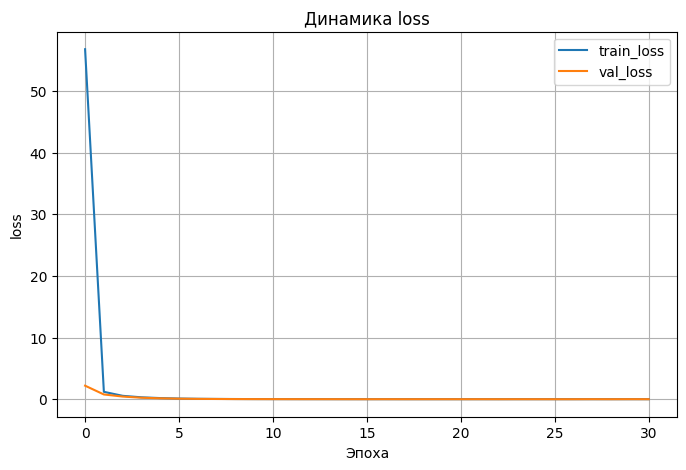

In [164]:
# визуализация потерь

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")

plt.title("Динамика loss")
plt.xlabel("Эпоха")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

plt.show()

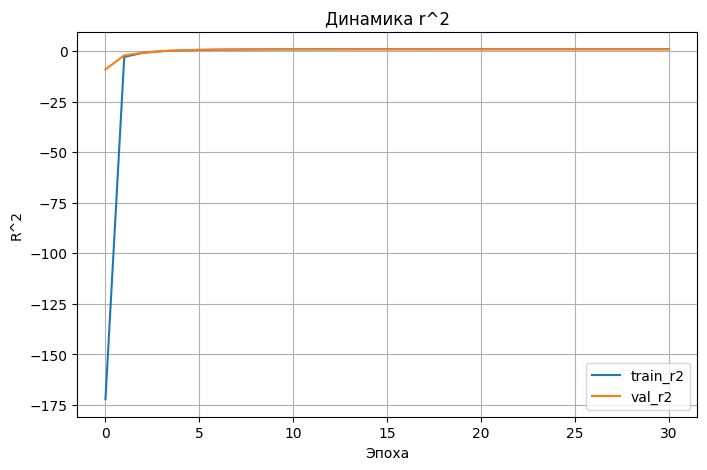

In [165]:
plt.figure(figsize=(8, 5))

plt.plot(train_r2s, label="train_r2")
plt.plot(val_r2s, label="val_r2")

plt.title("Динамика r^2")
plt.xlabel("Эпоха")
plt.ylabel("R^2")
plt.legend()
plt.grid(True)

plt.show()

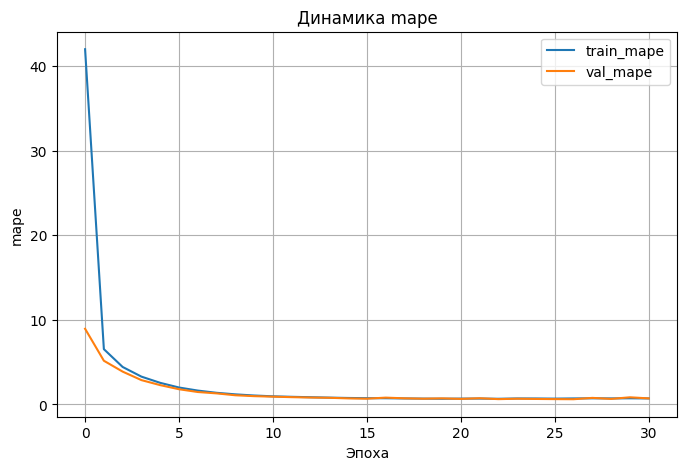

In [166]:
plt.figure(figsize=(8, 5))

plt.plot(train_mapes, label="train_mape")
plt.plot(val_mapes, label="val_mape")

plt.title("Динамика mape")
plt.xlabel("Эпоха")
plt.ylabel("mape")
plt.legend()
plt.grid(True)

plt.show()

In [167]:
# функция оценки на тестовом множестве

def evaluate_model(model, test_loader, criterion):
    """
    оценивает модель на тестовом множестве
    """

    model.eval()

    test_loss = 0.0
    test_r2 = 0.0
    test_mape = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs).flatten()

            loss = criterion(outputs, targets)

            test_loss += loss.item()
            test_r2 += r2_score(targets, outputs).item()
            test_mape += mape_score(targets, outputs).item()

    test_loss /= len(test_loader)
    test_r2 /= len(test_loader)
    test_mape /= len(test_loader)

    return test_loss, test_r2, test_mape

In [168]:
test_loss, test_r2, test_mape = evaluate_model(model, test_loader, criterion)

print("результаты на тестовом множестве:")
print("test_loss:", round(test_loss, 6))
print("test_r2:", round(test_r2, 6))
print("test_mape:", round(test_mape, 6))

результаты на тестовом множестве:
test_loss: 0.018567
test_r2: 0.944535
test_mape: 0.73634


<p class="task" id="3"></p>

3\. Перепишите логику обучения модели, используя `pytorch_lightning`. Для расчета метрик $R^2$ и MAPE используйте `torchmetrics`. Ранняя остановка в данном задании не требуется. После завершения обучения посчитайте значения метрик на тестовом множестве.

В процессе обучения настройки progressbar так, что:
* для каждого батча во время обучения рассчитывается значение функции потерь и метрик, по завершению эпохи показатели усредняются;
* для каждого батча во время валидации рассчитывается значение функции потерь и метрик, по завершению эпохи показатели усредняются.

- [ ] Проверено на семинаре

In [169]:
!pip install pytorch_lightning torchmetrics

In [170]:
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from torchmetrics.regression import R2Score, MeanAbsolutePercentageError

In [171]:
# переводим данные в тензоры pytorch

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [172]:
# создаем datamodule для удобной подачи данных в lightning

class WalmartDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
        super().__init__()

        # сохраняем все данные внутрь объекта
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        # создаем dataset для train, val, test
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.val_dataset = TensorDataset(self.X_val, self.y_val)
        self.test_dataset = TensorDataset(self.X_test, self.y_test)

        print("train:", len(self.train_dataset))
        print("val:", len(self.val_dataset))
        print("test:", len(self.test_dataset))

    def train_dataloader(self):
        # dataloader для обучения
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # dataloader для валидации
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        # dataloader для теста
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

In [173]:
# создание модели LightningModule

class WalmartRegressionModel(pl.LightningModule):
    def __init__(self, n_inputs, h_hidden=16, learning_rate=0.01):
        super().__init__()

        # сохраняем гиперпараметры
        self.save_hyperparameters()

        self.model = nn.Sequential(
            nn.Linear(n_inputs, h_hidden),
            nn.ReLU(),
            nn.Linear(h_hidden, 1)
        )

        self.loss_fn = nn.MSELoss()

        # метрики для обучения
        self.train_r2 = R2Score()
        self.train_mape = MeanAbsolutePercentageError()

        # метрики для валидации
        self.val_r2 = R2Score()
        self.val_mape = MeanAbsolutePercentageError()

        # метрики для теста
        self.test_r2 = R2Score()
        self.test_mape = MeanAbsolutePercentageError()

    def forward(self, x):
        # squeeze(1) превращает форму [batch, 1] в [batch]
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        # шаг обучения на одном батче

        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)

        # считаем метрики на текущем батче
        r2 = self.train_r2(y_pred, y)
        mape = self.train_mape(y_pred, y)

        # логируем так, чтобы:
        # on_step=True  -> лог на каждом батче
        # on_epoch=True -> усреднение по эпохе
        # prog_bar=True -> показывать в progress bar
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        # шаг валидации на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на текущем батче
        r2 = self.val_r2(y_pred, y)
        mape = self.val_mape(y_pred, y)

        # логируем на батче + усреднение по эпохе
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        # шаг тестирования на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на текущем батче
        r2 = self.test_r2(y_pred, y)
        mape = self.test_mape(y_pred, y)

        # логируем метрики теста
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        # оптимизатор для обучения
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

In [174]:
# задаем параметры обучения

batch_size = 32
learning_rate = 0.01
num_epochs = 50
hidden_size = 16
n_inputs = X_train.shape[1]

# создаем datamodule
data_module = WalmartDataModule(
X_train_tensor, y_train_tensor,
X_val_tensor, y_val_tensor,
X_test_tensor, y_test_tensor,
batch_size=batch_size
)

# создаем модель

model = WalmartRegressionModel(
n_inputs=n_inputs,
h_hidden=hidden_size,
learning_rate=learning_rate
)

In [175]:
# созданик trainer и обучение модели

trainer = pl.Trainer(
    max_epochs=num_epochs,
    enable_checkpointing=False,
    logger=False
)

trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


train: 4539
val: 930
test: 966


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Sequential                  │    129 │ train │     0 │
│ 1 │ loss_fn    │ MSELoss                     │      0 │ train │     0 │
│ 2 │ train_r2   │ R2Score                     │      0 │ train │     0 │
│ 3 │ train_mape │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 4 │ val_r2     │ R2Score                     │      0 │ train │     0 │
│ 5 │ val_mape   │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 6 │ test_r2    │ R2Score                     │      0 │ train │     0 │
│ 7 │ test_mape  │ MeanAbsolutePercentageError │      0 │ train │     0 │
└───┴────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 129                                                                                              
Non-trainable params: 0                                                                                            
Total params: 129                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [176]:
# запускаем тестирование после обучения

test_results = trainer.test(model, datamodule=data_module)
print(test_results)

Output()

train: 4539
val: 930
test: 966


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.3305440843105316     │
│         test_mape         │    0.03532712161540985    │
│          test_r2          │   0.009225229732692242    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.3305440843105316, 'test_r2': 0.009225229732692242, 'test_mape': 0.03532712161540985}]


In [177]:
# тестовые метрики

if len(test_results) > 0:
    result = test_results[0]

    print("test_loss =", result["test_loss"])
    print("test_r2 =", result["test_r2"])
    print("test_mape =", result["test_mape"])

test_loss = 0.3305440843105316
test_r2 = 0.009225229732692242
test_mape = 0.03532712161540985


<p class="task" id="4"></p>

4\. Повторите задачу 3, добавив логику ранней остановки, используя callback `pytorch_lightning`. Если значение функции потерь на валидационном множестве не улучшалось в течении 5 эпох, происходит ранняя остановка.

- [ ] Проверено на семинаре

In [178]:
from pytorch_lightning.callbacks import EarlyStopping

In [179]:
# создаем datamodule для удобной подачи данных в lightning

class WalmartDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
        super().__init__()

        # сохраняем все данные внутрь объекта
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        # создаем dataset для train, val, test
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.val_dataset = TensorDataset(self.X_val, self.y_val)
        self.test_dataset = TensorDataset(self.X_test, self.y_test)

        print("train:", len(self.train_dataset))
        print("val:", len(self.val_dataset))
        print("test:", len(self.test_dataset))

    def train_dataloader(self):
        # dataloader для обучения
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # dataloader для валидации
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        # dataloader для теста
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

In [180]:
# создаем lightning-модель для регрессии

class WalmartRegressionModel(pl.LightningModule):
    def __init__(self, n_inputs, h_hidden=16, learning_rate=0.01):
        super().__init__()

        # сохраняем гиперпараметры
        self.save_hyperparameters()

        # нейросеть для регрессии
        self.model = nn.Sequential(
            nn.Linear(n_inputs, h_hidden),
            nn.ReLU(),
            nn.Linear(h_hidden, 1)
        )

        # функция потерь
        self.loss_fn = nn.MSELoss()

        # метрики для обучения
        self.train_r2 = R2Score()
        self.train_mape = MeanAbsolutePercentageError()

        # метрики для валидации
        self.val_r2 = R2Score()
        self.val_mape = MeanAbsolutePercentageError()

        # метрики для теста
        self.test_r2 = R2Score()
        self.test_mape = MeanAbsolutePercentageError()

    def forward(self, x):
        # прямой проход
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        # шаг обучения на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на батче
        r2 = self.train_r2(y_pred, y)
        mape = self.train_mape(y_pred, y)

        # логируем на каждом батче и усредняем по эпохе
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        # шаг валидации на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на батче
        r2 = self.val_r2(y_pred, y)
        mape = self.val_mape(y_pred, y)


        # val_loss должен логироваться с on_epoch=True,
        # потому что early stopping будет следить за ним
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        # шаг тестирования

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики
        r2 = self.test_r2(y_pred, y)
        mape = self.test_mape(y_pred, y)

        # логируем только по эпохе для теста
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        # оптимизатор
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

In [181]:
# задаем параметры

batch_size = 32
learning_rate = 0.01
num_epochs = 100
hidden_size = 16
n_inputs = X_train.shape[1]

# создаем datamodule
data_module = WalmartDataModule(
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    X_test_tensor, y_test_tensor,
    batch_size=batch_size
)

# создаем модель
model = WalmartRegressionModel(
    n_inputs=n_inputs,
    h_hidden=hidden_size,
    learning_rate=learning_rate
)

In [182]:
# создаем callback ранней остановки

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    verbose=True
)

In [183]:
# создание Trainer с callback и обучение

trainer = pl.Trainer(
    max_epochs=num_epochs,
    callbacks=[early_stopping_callback],
    enable_checkpointing=False,
    logger=False
)

trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


train: 4539
val: 930
test: 966


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Sequential                  │    129 │ train │     0 │
│ 1 │ loss_fn    │ MSELoss                     │      0 │ train │     0 │
│ 2 │ train_r2   │ R2Score                     │      0 │ train │     0 │
│ 3 │ train_mape │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 4 │ val_r2     │ R2Score                     │      0 │ train │     0 │
│ 5 │ val_mape   │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 6 │ test_r2    │ R2Score                     │      0 │ train │     0 │
│ 7 │ test_mape  │ MeanAbsolutePercentageError │      0 │ train │     0 │
└───┴────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 129                                                                                              
Non-trainable params: 0                                                                                            
Total params: 129                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 4.822
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 2.187 >= min_delta = 0.0. New best score: 2.636
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.919 >= min_delta = 0.0. New best score: 1.717
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.390 >= min_delta = 0.0. New best score: 1.326
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.182 >= min_delta = 0.0. New best score: 1.144
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.021 >= min_delta = 0.0. New best score: 1.123
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.207 >= min_delta = 0.0. New best score: 0.916
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.890
INFO:pytorch_lightning.callbacks.ear

In [184]:
# запускаем тестирование после завершения обучения

test_results = trainer.test(model, datamodule=data_module)
print(test_results)

Output()

train: 4539
val: 930
test: 966


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.3845944404602051     │
│         test_mape         │    0.03657406568527222    │
│          test_r2          │    -0.1816667914390564    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.3845944404602051, 'test_r2': -0.1816667914390564, 'test_mape': 0.03657406568527222}]


In [185]:
# тестовые метрики

if len(test_results) > 0:
    result = test_results[0]

    print("test_loss =", result["test_loss"])
    print("test_r2 =", result["test_r2"])
    print("test_mape =", result["test_mape"])

test_loss = 0.3845944404602051
test_r2 = -0.1816667914390564
test_mape = 0.03657406568527222


<p class="task" id="5"></p>

5\. Повторите задачу 4, оформив набор данных в виде `pytorch_lightning.LightningDataModule`. Всю логику по созданию датасета (преобразования признаков, разбиение и т.д.) запакуйте в метод `setup`.

- [ ] Проверено на семинаре

In [186]:
# по сути DataModule становится контейнером для подготовки данных
# (выделение Х и у, разделение на выборки, масштабирование и тд)

In [187]:
# тут вся эта логика реализована

from torchmetrics.regression import R2Score, MeanAbsolutePercentageError

class WalmartDataModule(pl.LightningDataModule):
    def __init__(self, dataframe, target_column="Weekly_Sales", batch_size=32):
        super().__init__()

        # сохраняем исходный датафрейм и параметры
        self.dataframe = dataframe.copy()
        self.target_column = target_column
        self.batch_size = batch_size
        self.scaler = StandardScaler()

    def setup(self, stage=None):
        """
        копирование датафрейма
        обработка признаков
        кодирование категориальных признаков
        выделение X и y
        разбиение на train/val/test
        масштабирование
        перевод в тензоры
        создание TensorDataset
        """

        df = self.dataframe.copy()

        # обработка целевой переменной
        if self.target_column == "Weekly_Sales":
            df[self.target_column] = np.log1p(df[self.target_column])

        # кодирование категориальных признаков
        categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

        if self.target_column in categorical_columns:
            categorical_columns.remove(self.target_column)

        print("категориальные признаки:", categorical_columns)

        # one-hot encoding
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

        # выделяем признаки X и целевую переменную y
        X = df.drop(columns=[self.target_column])
        y = df[self.target_column]

        print("форма X:", X.shape)
        print("форма y:", y.shape)

        # разбиение на train / temp
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=0.3,       # 70% train, 30% временно
            random_state=42
        )

        # разбиение temp на val / test
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.5,
            random_state=42
        )

        print("размер train:", X_train.shape, y_train.shape)
        print("размер val:", X_val.shape, y_val.shape)
        print("размер test:", X_test.shape, y_test.shape)

        # масштабирование признаков
        # fit только на train, transform на val/test
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        # перевод в тензоры
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

        # создаем TensorDataset
        self.train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        self.val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        self.test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        # сохраним число признаков для модели
        self.num_features = X_train_tensor.shape[1]

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

In [188]:
# создаем lightning-модель для регрессии

class WalmartRegressionModel(pl.LightningModule):
    def __init__(self, n_inputs, h_hidden=16, learning_rate=0.01):
        super().__init__()

        # сохраняем гиперпараметры
        self.save_hyperparameters()

        # нейросеть для регрессии
        self.model = nn.Sequential(
            nn.Linear(n_inputs, h_hidden),
            nn.ReLU(),
            nn.Linear(h_hidden, 1)
        )

        # функция потерь
        self.loss_fn = nn.MSELoss()

        # метрики для обучения
        self.train_r2 = R2Score()
        self.train_mape = MeanAbsolutePercentageError()

        # метрики для валидации
        self.val_r2 = R2Score()
        self.val_mape = MeanAbsolutePercentageError()

        # метрики для теста
        self.test_r2 = R2Score()
        self.test_mape = MeanAbsolutePercentageError()

    def forward(self, x):
        # прямой проход
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        # шаг обучения на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на батче
        r2 = self.train_r2(y_pred, y)
        mape = self.train_mape(y_pred, y)

        # логируем на каждом батче и усредняем по эпохе
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        # шаг валидации на одном батче

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики на батче
        r2 = self.val_r2(y_pred, y)
        mape = self.val_mape(y_pred, y)


        # val_loss должен логироваться с on_epoch=True,
        # потому что early stopping будет следить за ним
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_r2", r2, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_mape", mape, on_step=True, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        # шаг тестирования

        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)

        # считаем метрики
        r2 = self.test_r2(y_pred, y)
        mape = self.test_mape(y_pred, y)

        # логируем только по эпохе для теста
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        # оптимизатор
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

In [189]:
# параметры
batch_size = 32

# создаем datamodule
data_module = WalmartDataModule(
    dataframe=df,                # <-- если у тебя другое имя датафрейма, поменяй здесь
    target_column="Weekly_Sales",
    batch_size=batch_size
)

# запускаем подготовку данных
data_module.setup()

категориальные признаки: []
форма X: (6435, 6)
форма y: (6435,)
размер train: (4504, 6) (4504,)
размер val: (965, 6) (965,)
размер test: (966, 6) (966,)


In [190]:
# параметры модели
hidden_size = 16
learning_rate = 0.01

# создаем модель
model = WalmartRegressionModel(
    n_inputs=data_module.num_features,
    h_hidden=hidden_size,
    learning_rate=learning_rate
)

# ранняя остановка: если val_loss не улучшается 5 эпох
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    verbose=True
)

In [191]:
# trainer и обучение

trainer = pl.Trainer(
    max_epochs=100,
    callbacks=[early_stopping_callback],
    enable_checkpointing=False,
    logger=False
)

trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


категориальные признаки: []
форма X: (6435, 6)
форма y: (6435,)
размер train: (4504, 6) (4504,)
размер val: (965, 6) (965,)
размер test: (966, 6) (966,)


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Sequential                  │    129 │ train │     0 │
│ 1 │ loss_fn    │ MSELoss                     │      0 │ train │     0 │
│ 2 │ train_r2   │ R2Score                     │      0 │ train │     0 │
│ 3 │ train_mape │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 4 │ val_r2     │ R2Score                     │      0 │ train │     0 │
│ 5 │ val_mape   │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 6 │ test_r2    │ R2Score                     │      0 │ train │     0 │
│ 7 │ test_mape  │ MeanAbsolutePercentageError │      0 │ train │     0 │
└───┴────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 129                                                                                              
Non-trainable params: 0                                                                                            
Total params: 129                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.041
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 0.011
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.005
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.003
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.002
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.002
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.002
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.002
INFO:pytorch_lightning.callbacks.ear

In [192]:
# тестирование
test_results = trainer.test(model, datamodule=data_module)
print(test_results)

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


категориальные признаки: []
форма X: (6435, 6)
форма y: (6435,)
размер train: (4504, 6) (4504,)
размер val: (965, 6) (965,)
размер test: (966, 6) (966,)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0016985735855996609   │
│         test_mape         │   0.012312537990510464    │
│          test_r2          │   -0.07655700296163559    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0016985735855996609, 'test_r2': -0.07655700296163559, 'test_mape': 0.012312537990510464}]


In [193]:
# вывод метрик

if len(test_results) > 0:
    result = test_results[0]

    print("test_loss =", result["test_loss"])
    print("test_r2 =", result["test_r2"])
    print("test_mape =", result["test_mape"])

test_loss = 0.0016985735855996609
test_r2 = -0.07655700296163559
test_mape = 0.012312537990510464


<p class="task" id="6"></p>

6\. Повторите задачу 5, добавив логирование при помощи `wandb`.

Вставьте в текстовую ячейку скриншоты, демонстрирующие интерфейс `wandb` со всеми нужными визуализациями.

- [ ] Проверено на семинаре

In [194]:
import wandb
wandb.login()

True

In [195]:
from pytorch_lightning.loggers import WandbLogger

In [196]:
# из 5й задачи

from torchmetrics.regression import R2Score, MeanAbsolutePercentageError

class WalmartDataModule(pl.LightningDataModule):
    def __init__(self, dataframe, target_column="Weekly_Sales", batch_size=32):
        super().__init__()

        # сохраняем исходный датафрейм и параметры
        self.dataframe = dataframe.copy()
        self.target_column = target_column
        self.batch_size = batch_size
        self.scaler = StandardScaler()
        self.num_features = None

    def setup(self, stage=None):
        """
        копирование датафрейма
        обработка признаков
        кодирование категориальных признаков
        выделение X и y
        разбиение на train/val/test
        масштабирование
        перевод в тензоры
        создание TensorDataset
        """

        df = self.dataframe.copy()

        # обработка целевой переменной
        if self.target_column == "Weekly_Sales":
            df[self.target_column] = np.log1p(df[self.target_column])

        # кодирование категориальных признаков
        categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

        if self.target_column in categorical_columns:
            categorical_columns.remove(self.target_column)

        print("категориальные признаки:", categorical_columns)

        # one-hot encoding
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

        # выделяем признаки X и целевую переменную y
        X = df.drop(columns=[self.target_column])
        y = df[self.target_column]

        print("форма X:", X.shape)
        print("форма y:", y.shape)

        # разбиение на train / temp
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=0.3,       # 70% train, 30% временно
            random_state=42
        )

        # разбиение temp на val / test
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.5,
            random_state=42
        )

        print("размер train:", X_train.shape, y_train.shape)
        print("размер val:", X_val.shape, y_val.shape)
        print("размер test:", X_test.shape, y_test.shape)

        # масштабирование признаков
        # fit только на train, transform на val/test
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)

        # перевод в тензоры
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

        # создаем TensorDataset
        self.train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        self.val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        self.test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        # сохраним число признаков для модели
        self.num_features = X_train_tensor.shape[1]

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

In [197]:
# LightningModule с метриками и логированием
# тут надо логировать метрики через self.log(...)
# wandb подхватит их из Lightning logger

class WalmartRegressionModel(pl.LightningModule):
    def __init__(self, n_inputs, h_hidden=16, learning_rate=0.01):
        super().__init__()

        self.save_hyperparameters()

        # модель
        self.model = nn.Sequential(
            nn.Linear(n_inputs, h_hidden),
            nn.ReLU(),
            nn.Linear(h_hidden, 1)
        )

        # loss
        self.loss_fn = nn.MSELoss()

        # train метрики
        self.train_r2 = R2Score()
        self.train_mape = MeanAbsolutePercentageError()

        # val метрики
        self.val_r2 = R2Score()
        self.val_mape = MeanAbsolutePercentageError()

        # test метрики
        self.test_r2 = R2Score()
        self.test_mape = MeanAbsolutePercentageError()

    def forward(self, x):
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)
        r2 = self.train_r2(y_pred, y)
        mape = self.train_mape(y_pred, y)

        # логирование train метрик
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)
        r2 = self.val_r2(y_pred, y)
        mape = self.val_mape(y_pred, y)

        # логирование val метрик
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)

        loss = self.loss_fn(y_pred, y)
        r2 = self.test_r2(y_pred, y)
        mape = self.test_mape(y_pred, y)

        # логирование test метрик
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_mape", mape, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

In [199]:
batch_size = 32
hidden_size = 16
learning_rate = 0.01
df = pd.read_csv("Walmart_sales.csv")


data_module = WalmartDataModule(
    dataframe=df,
    target_column="Weekly_Sales",
    batch_size=batch_size
)

data_module.setup()

model = WalmartRegressionModel(
    n_inputs=data_module.num_features,
    h_hidden=hidden_size,
    learning_rate=learning_rate
)

категориальные признаки: ['Date']
форма X: (6435, 148)
форма y: (6435,)
размер train: (4504, 148) (4504,)
размер val: (965, 148) (965,)
размер test: (966, 148) (966,)


In [200]:
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    verbose=True
)

wandb_logger = WandbLogger(
    project="walmart-sales-regression",
    name="task6-lightning-datamodule-earlystopping",
    log_model=False
)

# логирование гиперпараметров
wandb_logger.experiment.config.update({
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "hidden_size": hidden_size,
    "max_epochs": 100,
    "early_stopping_patience": 5,
    "target_column": "Weekly_Sales"
})

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


In [201]:
trainer = pl.Trainer(
    max_epochs=100,
    callbacks=[early_stopping_callback],
    logger=wandb_logger,
    enable_checkpointing=False
)

trainer.fit(model, datamodule=data_module)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


категориальные признаки: ['Date']
форма X: (6435, 148)
форма y: (6435,)
размер train: (4504, 148) (4504,)
размер val: (965, 148) (965,)
размер test: (966, 148) (966,)


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Sequential                  │  2.4 K │ train │     0 │
│ 1 │ loss_fn    │ MSELoss                     │      0 │ train │     0 │
│ 2 │ train_r2   │ R2Score                     │      0 │ train │     0 │
│ 3 │ train_mape │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 4 │ val_r2     │ R2Score                     │      0 │ train │     0 │
│ 5 │ val_mape   │ MeanAbsolutePercentageError │      0 │ train │     0 │
│ 6 │ test_r2    │ R2Score                     │      0 │ train │     0 │
│ 7 │ test_mape  │ MeanAbsolutePercentageError │      0 │ train │     0 │
└───┴────────────┴─────────────────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.854
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.315 >= min_delta = 0.0. New best score: 0.539
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.049 >= min_delta = 0.0. New best score: 0.490
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.018 >= min_delta = 0.0. New best score: 0.472
INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.472. Signaling Trainer to stop.


In [202]:
test_results = trainer.test(model, datamodule=data_module)
print(test_results)

wandb.finish()

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     0.526271641254425     │
│         test_mape         │    0.04352413862943649    │
│          test_r2          │    -0.6051673889160156    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.526271641254425, 'test_r2': -0.6051673889160156, 'test_mape': 0.04352413862943649}]


epoch,▁▁▂▂▂▂▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
test_loss,▁
test_mape,▁
test_r2,▁
train_loss,█▁▁▁▁▁▁▁▁▁
train_mape,█▁▁▁▁▁▁▁▁▁
train_r2,▁█████████
trainer/global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇███
val_loss,█▂▁▁▁▂▃▃▂▂
val_mape,▆▃▂▃▁▃▇█▃▄
+1,...


In [203]:
# вывод тестовых метрик
if len(test_results) > 0:
    result = test_results[0]

    print("test_loss =", result["test_loss"])
    print("test_r2 =", result["test_r2"])
    print("test_mape =", result["test_mape"])

test_loss = 0.526271641254425
test_r2 = -0.6051673889160156
test_mape = 0.04352413862943649


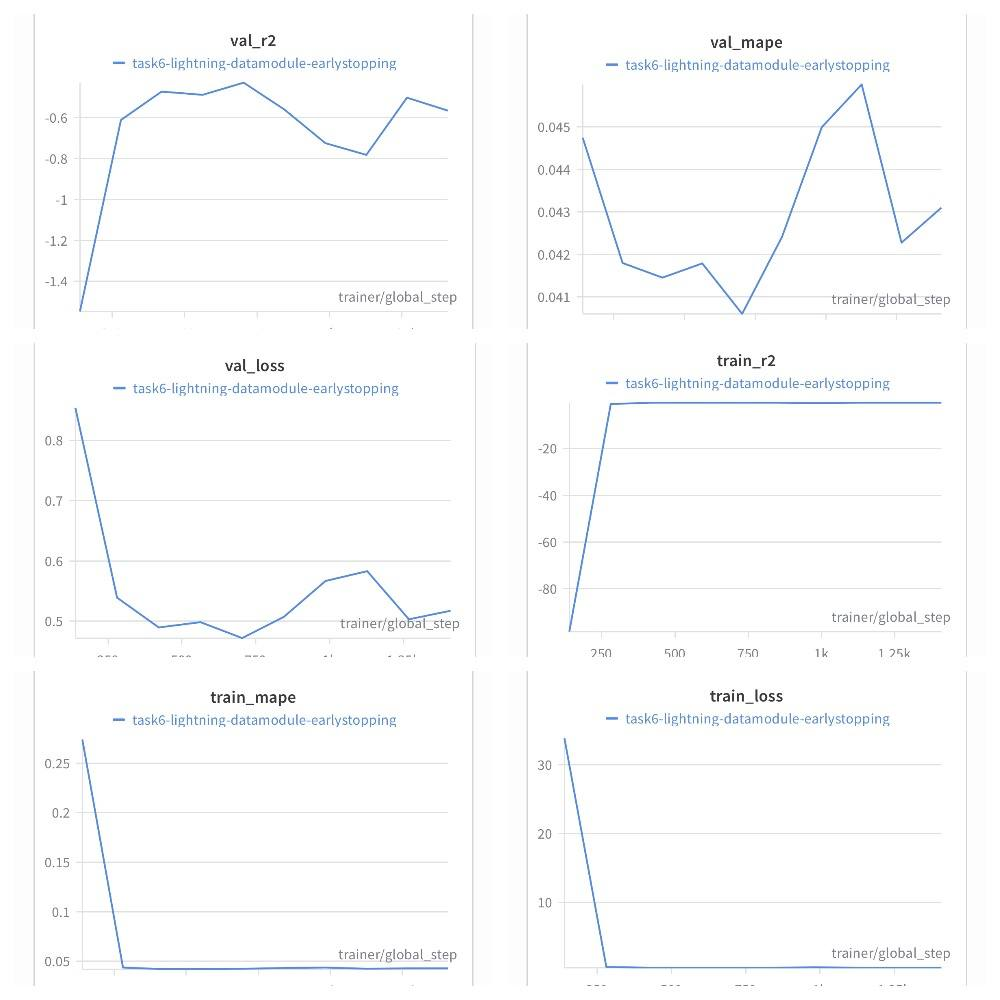